(array([-20.,   0.,  20.,  40.,  60.,  80., 100., 120.]),
 [Text(0, -20.0, '−20'),
  Text(0, 0.0, '0'),
  Text(0, 20.0, '20'),
  Text(0, 40.0, '40'),
  Text(0, 60.0, '60'),
  Text(0, 80.0, '80'),
  Text(0, 100.0, '100'),
  Text(0, 120.0, '120')])

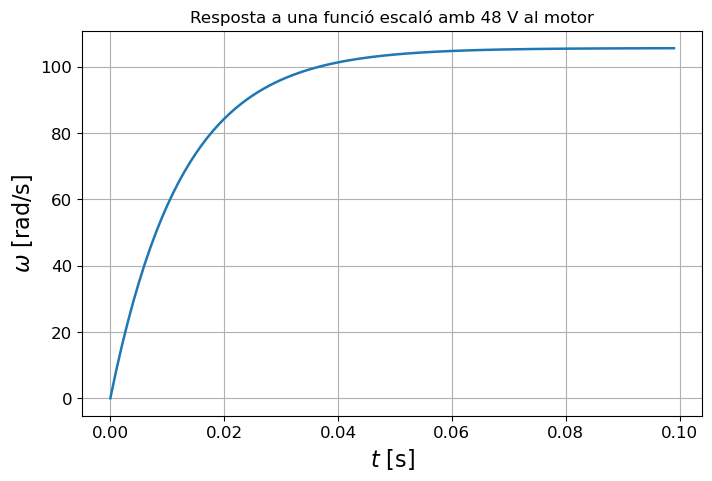

In [1]:
# Equivalent en Python amb scipy.signal
# Identificar el model, el diagrama de Bode, i implementar PI
# Adaptació des de Matlab
# J.A. Mayugo, UdG, 2023

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------------------------
# Propietats del sistema
# -------------------------------------------------------------------------

U = 48          # V, input 'bump test'
A = 2.20        # rad/sV
B = 12.5e-3     # s

omega_n = 80    # rad/s
zeta = 0.90     # críticament esmorteït

t_ = np.arange(0, 0.1, 0.001)   # resposta temporal

# -------------------------------------------------------------------------
# APARTAT b)
# -------------------------------------------------------------------------

tau = B
K = A

# Funció de transferència del motor:
#
#               K
# Gm(s) = -------------
#          tau*s + 1
#

num_Gm = [K]
den_Gm = [tau, 1]

G_m = signal.TransferFunction(num_Gm, den_Gm)

# -------------------------------------------------------------------------
# Resposta en llaç obert
# -------------------------------------------------------------------------

U_ = U * np.ones_like(t_)

# lsim equivalent
t_out, omg, x = signal.lsim(G_m, U_, t_)

H_ol = plt.figure(figsize=(8, 5))
plt.plot(t_out, omg, linewidth=1.8)

plt.grid(True)
plt.title(f"Resposta a una funció escaló amb {U} V al motor")

plt.xlabel(r"$t$ [s]", fontsize=16)
plt.ylabel(r"$\omega$ [rad/s]", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


Pols del sistema en llaç obert:
[-80.]


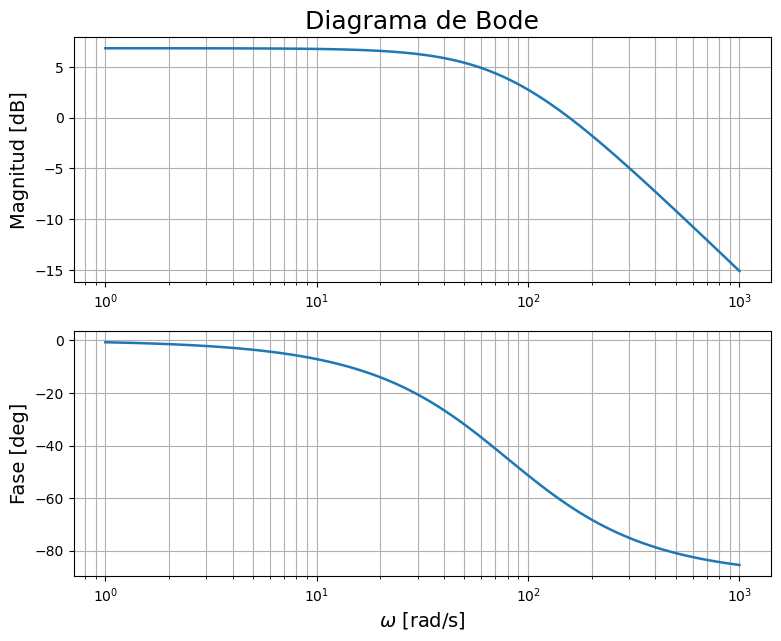

In [2]:
# -------------------------------------------------------------------------
# Diagrama de Bode
# -------------------------------------------------------------------------

w, mag, phase = signal.bode(G_m)

H_bode = plt.figure(figsize=(9, 7))

# Magnitud
plt.subplot(2, 1, 1)
plt.semilogx(w, mag, linewidth=1.8)
plt.grid(True, which='both')
plt.ylabel("Magnitud [dB]", fontsize=14)
plt.title("Diagrama de Bode", fontsize=18)

# Fase
plt.subplot(2, 1, 2)
plt.semilogx(w, phase, linewidth=1.8)
plt.grid(True, which='both')

plt.xlabel(r"$\omega$ [rad/s]", fontsize=14)
plt.ylabel("Fase [deg]", fontsize=14)

# -------------------------------------------------------------------------
# Pols del sistema
# -------------------------------------------------------------------------

p = np.roots(den_Gm)

print("\nPols del sistema en llaç obert:")
print(p)


Guanys del controlador PI:
Kp = 0.3636
Ki = 36.3636

Pols del sistema en llaç tancat:
[-72.+34.87119155j -72.-34.87119155j]


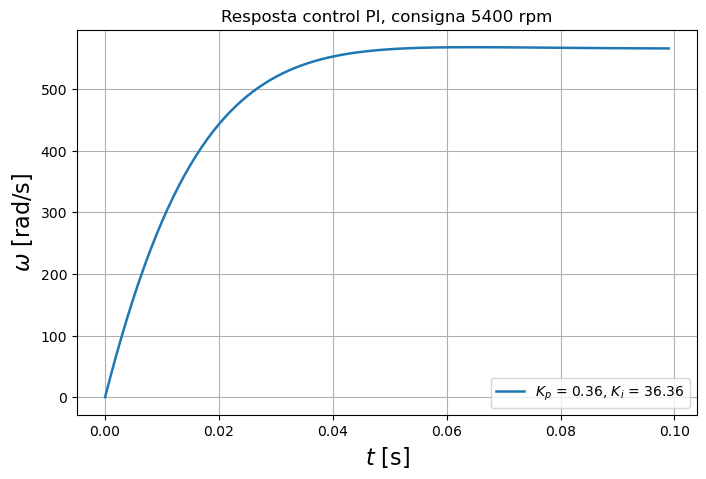

In [3]:
# -------------------------------------------------------------------------
# Control velocitat llaç tancat
# considerant un sistema de 2n ordre
# -------------------------------------------------------------------------

Kp = (2 * zeta * omega_n * tau - 1) / K
Ki = (omega_n**2 * tau) / K

print("\nGuanys del controlador PI:")
print(f"Kp = {Kp:.4f}")
print(f"Ki = {Ki:.4f}")

num_PI = [Kp, Ki]
den_PI = [1, 0]

num_ol = np.polymul(num_PI, num_Gm)
den_ol = np.polymul(den_PI, den_Gm)

den_cl = np.polyadd(den_ol, num_ol)
num_cl = num_ol

G_cl = signal.TransferFunction(num_cl, den_cl)

# -------------------------------------------------------------------------
# Pols en llaç tancat
# -------------------------------------------------------------------------

p_cl = np.roots(den_cl)

print("\nPols del sistema en llaç tancat:")
print(p_cl)

# -------------------------------------------------------------------------
# Resposta temporal llaç tancat
# -------------------------------------------------------------------------

u = 5400    # rpm

# Conversió rpm -> rad/s
u_ = (u / 30) * np.pi * np.ones_like(t_)

t_out, omg_cl, x = signal.lsim(G_cl, u_, t_)

H_cl = plt.figure(figsize=(8, 5))

plt.plot(t_out, omg_cl, linewidth=1.8)
plt.grid(True)
plt.title(f"Resposta control PI, consigna {u} rpm")
plt.xlabel(r"$t$ [s]", fontsize=16)
plt.ylabel(r"$\omega$ [rad/s]", fontsize=16)
plt.legend([rf"$K_p$ = {Kp:.2f}, $K_i$ = {Ki:.2f}"], loc='lower right')

plt.show()